# Assignment 2

The data for this assignment comes from a subset of The National Centers for Environmental Information (NCEI) [Global Historical Climatology Network daily (GHCNd)](https://www.ncei.noaa.gov/products/land-based-station/global-historical-climatology-network-daily) (GHCN-Daily). The GHCN-Daily is comprised of daily climate records from thousands of land surface stations across the globe. You will be asked to use data from Ann Arbor Michigan

Each row in this datafile corresponds to a single observation from a weather station, and has the following variables:
* **id** : station identification code
* **date** : date in YYYY-MM-DD format (e.g. 2012-01-24 = January 24, 2012)
* **element** : indicator of element type
    * TMAX : Maximum temperature (tenths of degrees C)
    * TMIN : Minimum temperature (tenths of degrees C)
* **value** : data value for element (tenths of degrees C)

For this assignment, you must:

1. Read the documentation and familiarize yourself with the dataset, then write a python notebook which plots line graphs of the record high and record low temperatures by day of the year over the period 2005-2014. The area between the record high and record low temperatures for each day should be shaded.
2. Overlay a scatter of the 2015 data for any points (highs and lows) for which the ten year record (2005-2014) record high or record low was broken in 2015. (Based on the graph, do you think extreme weather is getting more frequent in 2015?)
3. Watch out for leap days (i.e. February 29th), it is reasonable to remove these points from the dataset for the purpose of this visualization.
4. Leverage principles from the first module in this course when developing your solution. Consider issues such as legends, labels, and chart junk.

### Read & Wrangle

In [1]:
import pandas as pd
df = pd.read_csv('/kaggle/input/temperature-data-set-20052015-michigan-usa/fb441e62df2d58994928907a91895ec62c2c42e6cd075c2700843b89.csv')
df.head()

,ID,Date,Element,Data_Value
0,USW00094889,2014-11-12,TMAX,22
1,USC00208972,2009-04-29,TMIN,56
2,USC00200032,2008-05-26,TMAX,278
3,USC00205563,2005-11-11,TMAX,139
4,USC00200230,2014-02-27,TMAX,-106


In [2]:
# Convert temp to Celsius
df_wrangle = df.copy()
df_wrangle['Data_Value'] = df_wrangle['Data_Value']*0.10
df_wrangle['Date365'] = pd.to_datetime(df_wrangle['Date']).transform(lambda x: x.strftime('%m-%d'))

# Remove observations on leap days
leapDays = df_wrangle[df_wrangle['Date365'] == '02-29'].index
df_wrangle.drop(leapDays,inplace=True)

# Groupby day of the year (365)
df_2005to2014 = df_wrangle[(df_wrangle['Date'] < '2015-01-01')].groupby('Date365').agg({'Data_Value': ['min','max']})
df_2015 = df_wrangle[(df_wrangle['Date'] > '2014-12-31')].groupby('Date365').agg({'Data_Value': ['min','max']})

In [3]:
# calculate the minimum and maximum values for the day of the year for 2005 through 2014
df_tmin_2005to2014 = df_2005to2014.xs('min', level=1, axis=1)
df_tmax_2005to2014 =  df_2005to2014.xs('max', level=1, axis=1)

# calculate the minimum and maximum values for the years 2015
df_tmin_2015 = df_2015.xs('min', level=1, axis=1)
df_tmax_2015 = df_2015.xs('max', level=1, axis=1)

In [4]:
# Extract 2015 observations where temperature is more extreme (hotter or colder) than 2005-2014 record
## Create boolean mask for each date range
compareMax = df_tmax_2015 > df_tmax_2005to2014
compareMin = df_tmin_2015 < df_tmin_2005to2014

## Filter 2015 dfs based on mask
plot_tmin2015 = df_tmin_2015[compareMin['Data_Value']==True]
plot_tmax2015 = df_tmax_2015[compareMax['Data_Value']==True]

### Plot Data

/opt/conda/lib/python3.10/site-packages/matplotlib/text.py:758: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(self._y))


''

/opt/conda/lib/python3.10/site-packages/matplotlib/text.py:898: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))


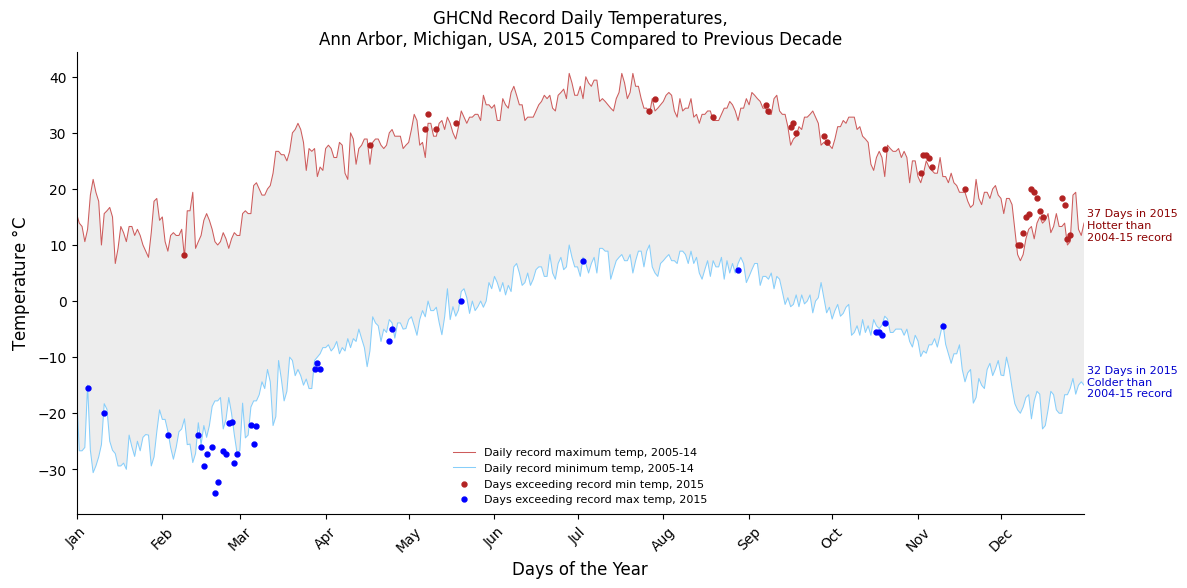

In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import matplotlib.dates as mdates
from calendar import month_abbr

## SETUP
plt.figure(figsize=(13,6))
plt.margins(x=0)
ax = plt.gca()
x = ax.xaxis


## DATA PLOTS

# Line Plot(1) - Max Temps 2005-2014
plt.plot(df_tmax_2005to2014.index, df_tmax_2005to2014['Data_Value'], lw=.75, c='indianred', alpha=1, zorder=1, label='Daily record maximum temp, 2005-14')
# Line Plot(2) - Min Temps 2005-2014
plt.plot(df_tmin_2005to2014.index, df_tmin_2005to2014['Data_Value'], lw=.75, c='lightskyblue', alpha=1, zorder=1, label='Daily record minimum temp, 2005-14')

# Scatterplot(1) - Max Temps 2015            
plt.scatter(plot_tmax2015.index, plot_tmax2015['Data_Value'], c='firebrick', marker='.', s=50, zorder=2, label='Days exceeding record min temp, 2015')
# Scatterplot(2) - Min Temps 2015
plt.scatter(plot_tmin2015.index, plot_tmin2015['Data_Value'], c='b', marker='.', s=50, zorder=2, label='Days exceeding record max temp, 2015')

# Format space between line plots
ax.fill_between(range(len(df_tmax_2005to2014.index)), 
                       df_tmin_2005to2014['Data_Value'], df_tmax_2005to2014['Data_Value'], 
                       facecolor='lightgrey', alpha=0.4, zorder=0)

## LEGEND
ax.legend(fontsize=8, frameon=False, loc='lower center')

## ADD TEXT TO LINEPLOTS
plt.text(365, df_tmax_2005to2014.iloc[-1]-3, str(len(plot_tmax2015))+' Days in 2015\nHotter than\n2004-15 record', fontsize=8, c='darkred')
plt.text(365, df_tmin_2005to2014.iloc[-1]-2, str(len(plot_tmin2015))+' Days in 2015\nColder than\n2004-15 record', fontsize=8, c='mediumblue')

## FORMATTING
# Title
ax.set_title("GHCNd Record Daily Temperatures,\nAnn Arbor, Michigan, USA, 2015 Compared to Previous Decade", fontsize=12)

# Axis
ax.set_xlabel('Days of the Year', fontsize=12)
ax.set_ylabel('Temperature $\degree$C', fontsize=12)

# Spines
# Make top and left invisible
ax.spines['top'].set_visible(False) 
ax.spines['right'].set_visible(False)

# Tickmarks
# Set num of ticks to months
ax.xaxis.set_major_locator(mdates.MonthLocator()) 
# Format ticks to abbreviated month names
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Rotate the tick labels for the x axis
for item in x.get_ticklabels():
    item.set_rotation(45)


## SAVE FIGURE
plt.savefig('Plot_Assignment2.png', dpi=300, pad_inches=1, transparent=False) 
;
